<a href="https://colab.research.google.com/github/mahla-aghapour/B101-Group2-NLP-Project/blob/main/DetectorModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q numpy pandas torch datasets transformers sentencepiece protobuf accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


In [3]:
import gc
import torch
import pandas as pd
import numpy as np
import evaluate

from google.colab import files
from datasets import Dataset
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# ============================================================
# PREPARE THE INFORMAL DATASET
# ============================================================

# Upload only informal_samples.csv
uploaded = files.upload()

# Load the informal training dataset
train_df = pd.read_csv(
    "/content/informal_samples.csv",
    encoding="latin-1"
)

print(f"Shape of train_df: {train_df.shape}")
display(train_df.head())

# Convert the informal dataset to a Hugging Face Dataset
raw_dataset = Dataset.from_pandas(train_df)

# Encode AI_label as ClassLabel so the split can be stratified
raw_dataset = raw_dataset.class_encode_column("AI_label")

# Create internal training and validation sets
dataset = raw_dataset.train_test_split(
    test_size=0.2,
    seed=42,
    shuffle=True,
    stratify_by_column="AI_label"
)

# Rename the internal test split to val
dataset["val"] = dataset.pop("test")

print(dataset)

# Expected:
# train: 4320
# val: 1080


# ============================================================
# TOKENIZATION
# ============================================================

model = "microsoft/deberta-v3-small"

tokenizer = AutoTokenizer.from_pretrained(
    model,
    use_fast=True
)

def tokenize(example):
    tokenized = tokenizer(
        example["sample_text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

    tokenized["labels"] = example["AI_label"]

    return tokenized

tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=["sample_text"]
)

print(tokenized_dataset)


# ============================================================
# METRICS SETUP
# ============================================================

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_metric.compute(
        predictions=preds,
        references=labels
    )["accuracy"]

    # Precision, recall and F1
    (
        precision_macro,
        recall_macro,
        f1_macro,
        _
    ) = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    (
        _,
        _,
        f1_weighted,
        _
    ) = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    # ROC AUC
    try:
        auc = roc_auc_score(
            labels,
            logits[:, 1]
        )
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "auc": auc
    }


# ============================================================
# JEFFREY'S HYPERPARAMETER-TUNING CODE
# ============================================================

baseline_params = {
    "learning_rate": 1.0e-05,
    "weight_decay": 0.01,
    "warmup_steps": 115,
    "per_device_train_batch_size": 16,
    "label_smoothing_factor": 0.05,
}

param_variations = {
    "learning_rate": [1.0e-06, 1.0e-05, 1.0e-04],
    "weight_decay": [0.005, 0.01, 0.025],
    "warmup_steps": [50, 115, 200],
    "per_device_train_batch_size": [8, 16, 32],
    "label_smoothing_factor": [0.0, 0.05, 0.1],
}

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        "microsoft/deberta-v3-small",
        num_labels=2,
        id2label={
            0: "Human-Written",
            1: "AI-Generated"
        },
        label2id={
            "Human-Written": 0,
            "AI-Generated": 1
        },
    )

results = []
run_count = 1

for param_name, values in param_variations.items():
    print("\n==========================================")
    print(f" TESTING HYPERPARAMETER: {param_name} ")
    print("==========================================")

    for val in values:
        current_config = baseline_params.copy()
        current_config[param_name] = val

        print(f"\n[Run {run_count}/15] {param_name} = {val}")

        gc.collect()
        torch.cuda.empty_cache()

        training_args = TrainingArguments(
            seed=42,
            output_dir=f"./results_grid_{param_name}_{val}",
            num_train_epochs=3,

            per_device_train_batch_size=(
                current_config[
                    "per_device_train_batch_size"
                ]
            ),

            per_device_eval_batch_size=16,

            learning_rate=(
                current_config["learning_rate"]
            ),

            weight_decay=(
                current_config["weight_decay"]
            ),

            warmup_steps=(
                current_config["warmup_steps"]
            ),

            label_smoothing_factor=(
                current_config[
                    "label_smoothing_factor"
                ]
            ),

            lr_scheduler_type="cosine",

            optim=(
                "adamw_torch_fused"
                if torch.cuda.is_available()
                else "adamw_torch"
            ),

            adam_epsilon=1e-6,
            max_grad_norm=0.5,

            fp16=False,
            bf16=torch.cuda.is_bf16_supported(),

            eval_strategy="steps",
            eval_steps=45,

            save_strategy="steps",
            save_steps=45,
            save_total_limit=1,

            logging_steps=15,

            metric_for_best_model="accuracy",
            greater_is_better=True,
            load_best_model_at_end=True,
            report_to="none"
        )

        trainer = Trainer(
            model_init=model_init,
            args=training_args,
            train_dataset=tokenized_dataset["train"],
            eval_dataset=tokenized_dataset["val"],
            compute_metrics=compute_metrics,
            callbacks=[
                EarlyStoppingCallback(
                    early_stopping_patience=3
                )
            ]
        )

        trainer.train()

        metrics = trainer.evaluate()

        results.append({
            "tested_parameter": param_name,
            "tested_value": val,
            "eval_accuracy": metrics["eval_accuracy"],
            "eval_f1_macro": metrics["eval_f1_macro"],
            "eval_loss": metrics["eval_loss"]
        })

        run_count += 1

summary_df = pd.DataFrame(results)

display(
    summary_df.sort_values(
        by=[
            "tested_parameter",
            "eval_accuracy"
        ],
        ascending=[
            True,
            False
        ]
    )
)

Saving informal_samples.csv to informal_samples.csv
Shape of train_df: (5400, 3)


,sample_text,sub-type,AI_label
0,it was the best of times it was the worst of t...,message,0
1,I will come with karnan car. Please wait till ...,message,0
2,yeah but dude i did that mistake some time ago...,message,0
3,in case of fire read this message i said in ca...,message,0
4,Yes just finished watching days of our lives. ...,message,0


Stringifying the column:   0%|          | 0/5400 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/5400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 1080
    })
})


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Auc
0.292839,0.354099,225,0.972222,0.972213,0.972213,0.972871,0.972222,0.997649


,tested_parameter,tested_value,eval_accuracy,eval_f1_macro,eval_loss
13,label_smoothing_factor,0.050000,0.973148,0.973138,0.272117
14,label_smoothing_factor,0.100000,0.972222,0.972213,0.354099
12,label_smoothing_factor,0.000000,0.810185,0.803091,1.399352
0,learning_rate,0.000001,0.987963,0.987962,0.156479
1,learning_rate,0.000010,0.973148,0.973138,0.272117
2,learning_rate,0.000100,0.773148,0.762663,0.740445
10,per_device_train_batch_size,16.000000,0.973148,0.973138,0.272117
11,per_device_train_batch_size,32.000000,0.963889,0.963855,0.231213
9,per_device_train_batch_size,8.000000,0.943519,0.943402,0.245007
8,warmup_steps,200.000000,0.975926,0.975912,0.178040


## GRAPHS

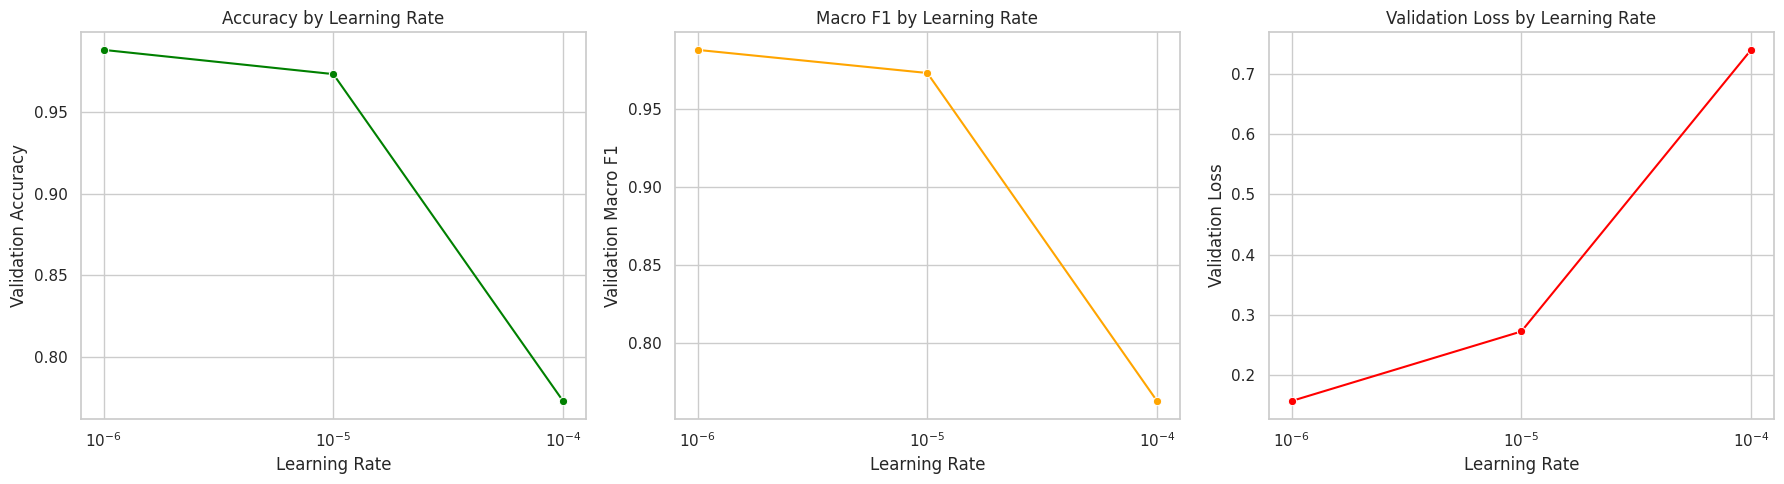

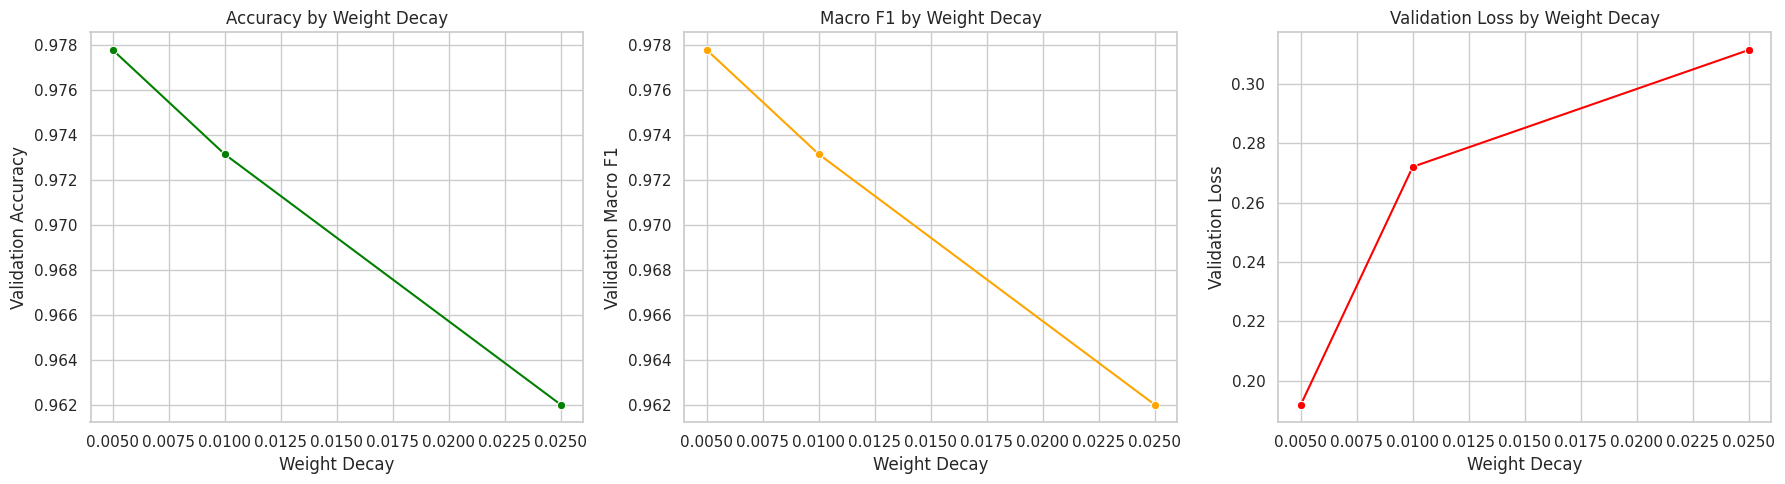

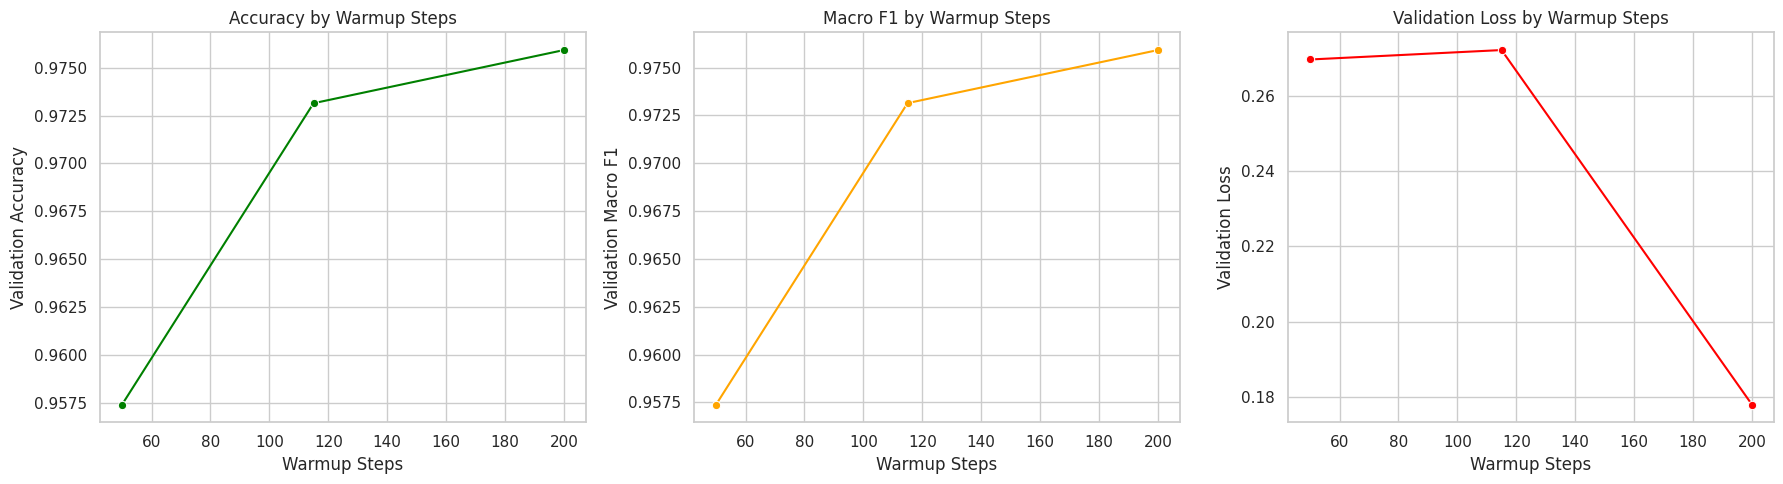

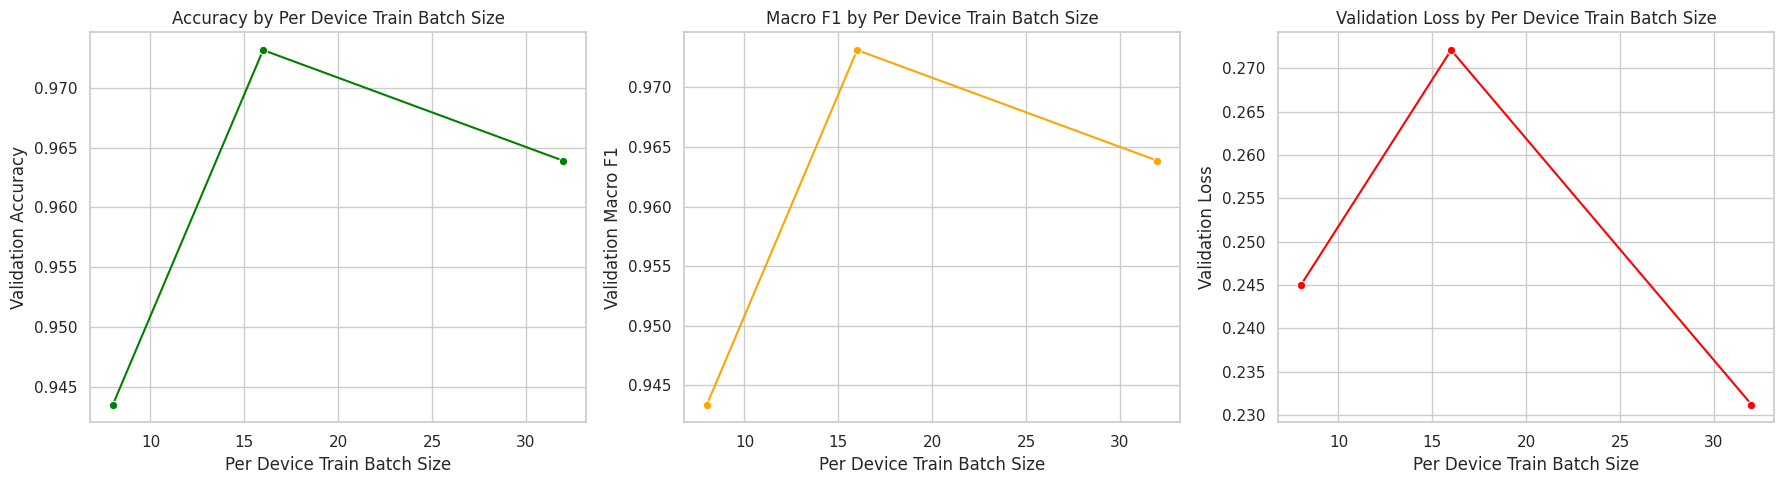

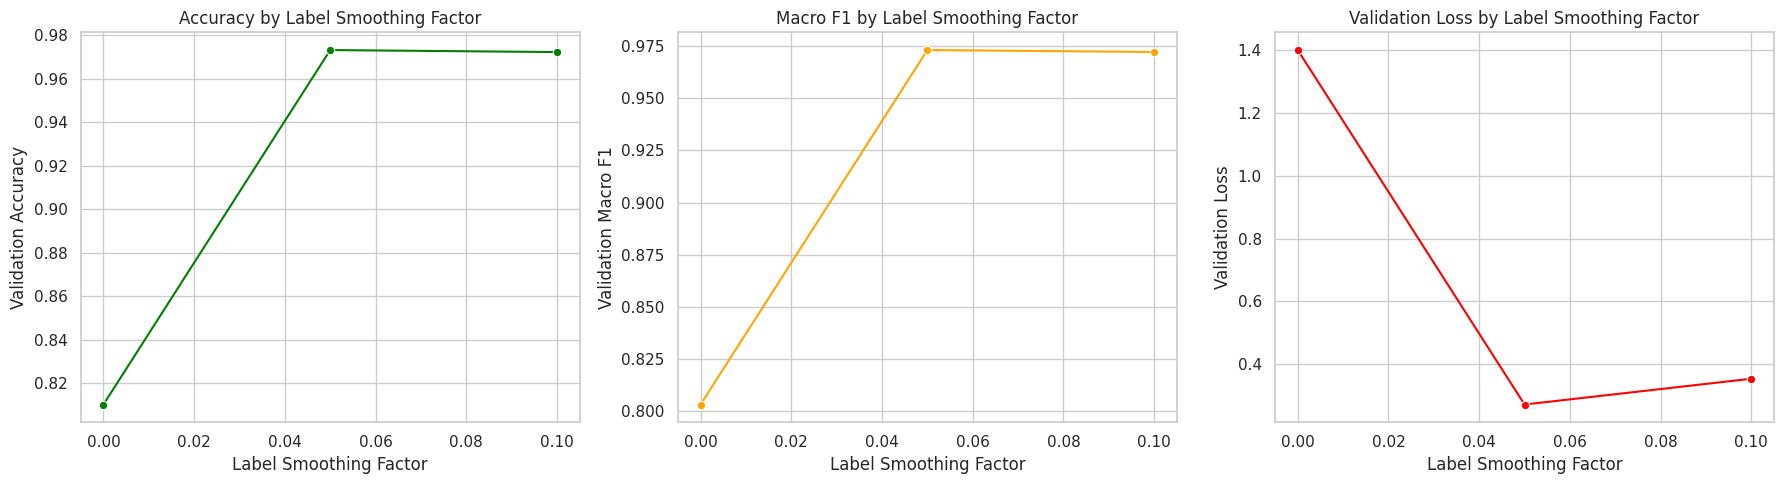

Graphs saved in: /content/informal_tuning_output/graphs


In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = "/content/informal_tuning_output"
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")

os.makedirs(GRAPH_DIR, exist_ok=True)

# Save the complete tuning results
sorted_summary_df = summary_df.sort_values(
    by=[
        "tested_parameter",
        "eval_accuracy"
    ],
    ascending=[
        True,
        False
    ]
)

sorted_summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "informal_hyperparameter_results.csv"
    ),
    index=False
)

sns.set_theme(style="whitegrid")

for parameter in param_variations.keys():

    parameter_results = summary_df[
        summary_df["tested_parameter"] == parameter
    ].copy()

    parameter_results = parameter_results.sort_values(
        by="tested_value"
    )

    friendly_name = parameter.replace("_", " ").title()

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )

    # Accuracy graph
    sns.lineplot(
        data=parameter_results,
        x="tested_value",
        y="eval_accuracy",
        marker="o",
        color="green",
        ax=axes[0]
    )

    axes[0].set_title(
        f"Accuracy by {friendly_name}"
    )
    axes[0].set_xlabel(friendly_name)
    axes[0].set_ylabel("Validation Accuracy")

    # Macro F1 graph
    sns.lineplot(
        data=parameter_results,
        x="tested_value",
        y="eval_f1_macro",
        marker="o",
        color="orange",
        ax=axes[1]
    )

    axes[1].set_title(
        f"Macro F1 by {friendly_name}"
    )
    axes[1].set_xlabel(friendly_name)
    axes[1].set_ylabel("Validation Macro F1")

    # Validation loss graph
    sns.lineplot(
        data=parameter_results,
        x="tested_value",
        y="eval_loss",
        marker="o",
        color="red",
        ax=axes[2]
    )

    axes[2].set_title(
        f"Validation Loss by {friendly_name}"
    )
    axes[2].set_xlabel(friendly_name)
    axes[2].set_ylabel("Validation Loss")

    # Learning rates are easier to read on a logarithmic scale
    if parameter == "learning_rate":
        for axis in axes:
            axis.set_xscale("log")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            GRAPH_DIR,
            f"{parameter}_comparison.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("Graphs saved in:", GRAPH_DIR)

In [5]:
import shutil
from google.colab import files

zip_path = shutil.make_archive(
    "/content/informal_hyperparameter_tuning_results",
    "zip",
    root_dir="/content",
    base_dir="informal_tuning_output"
)

print("ZIP created:", zip_path)

files.download(zip_path)

ZIP created: /content/informal_hyperparameter_tuning_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>